# Medigan

**Goal**: Exploring a collection of pre-trained GANs called medigan. Medigan generate a variety of medical images, such as MRIs and X-rays of various body parts. The project uses synthetic data to train a model to classify which parts of the medical image are of concern.

**Objectives**

- Look at the Medigan collection of pre-trained medical image GANs.
- Get descriptions of GANs and select the ones we want.
- Generate images with a selected GAN.
- Turn the GAN images into a data loader.
- Train a model using the generated images.

In [83]:
from pathlib import Path

import matplotlib.pyplot as plt
import medigan
import torch
import torch.optim as optim
import torchvision
from torchvision.io import read_image
from torchvision.utils import make_grid
from tqdm.notebook import tqdm

In [84]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


**Medigan Models**

In [85]:
generators = medigan.Generators()
generators.list_models()

['00001_DCGAN_MMG_CALC_ROI',
 '00002_DCGAN_MMG_MASS_ROI',
 '00003_CYCLEGAN_MMG_DENSITY_FULL',
 '00004_PIX2PIX_MMG_MASSES_W_MASKS',
 '00005_DCGAN_MMG_MASS_ROI',
 '00006_WGANGP_MMG_MASS_ROI',
 '00007_INPAINT_BRAIN_MRI',
 '00008_C-DCGAN_MMG_MASSES',
 '00009_PGGAN_POLYP_PATCHES_W_MASKS',
 '00010_FASTGAN_POLYP_PATCHES_W_MASKS',
 '00011_SINGAN_POLYP_PATCHES_W_MASKS',
 '00012_C-DCGAN_MMG_MASSES',
 '00013_CYCLEGAN_MMG_DENSITY_OPTIMAM_MLO',
 '00014_CYCLEGAN_MMG_DENSITY_OPTIMAM_CC',
 '00015_CYCLEGAN_MMG_DENSITY_CSAW_MLO',
 '00016_CYCLEGAN_MMG_DENSITY_CSAW_CC',
 '00017_DCGAN_XRAY_LUNG_NODULES',
 '00018_WGANGP_XRAY_LUNG_NODULES',
 '00019_PGGAN_CHEST_XRAY',
 '00020_PGGAN_CHEST_XRAY',
 '00021_CYCLEGAN_BRAIN_MRI_T1_T2',
 '00022_WGAN_CARDIAC_AGING',
 '00023_PIX2PIXHD_BREAST_DCEMRI']

Each one has an id number (the first number in the name) and somewhat a descriptive name. The configurations tell us what the model does. The `model_id` can either be the id or the whole name.

In [86]:
model_00001_config = generators.get_config_by_id(model_id=1)
model_00001_config

{'execution': {'package_name': '00001_DCGAN_MMG_CALC_ROI',
  'package_link': 'https://zenodo.org/record/7031735/files/00001_DCGAN_MMG_CALC_ROI.zip?download=1',
  'model_name': 'DCGAN',
  'extension': '.pt',
  'image_size': [128, 128],
  'dependencies': ['numpy', 'Path', 'torch', 'opencv-contrib-python-headless'],
  'generate_method': {'name': 'generate',
   'args': {'base': ['model_file',
     'num_samples',
     'output_path',
     'save_images'],
    'custom': {'image_size': 128}},
   'input_latent_vector_size': 100}},
 'selection': {'performance': {'SSIM': None,
   'MSE': None,
   'NSME': None,
   'PSNR': None,
   'IS': None,
   'turing_test': None,
   'FID_no_images': 1000,
   'FID': 67.6,
   'FID_ratio': 0.497,
   'FID_RADIMAGENET': 1.27,
   'FID_RADIMAGENET_ratio': 0.197,
   'CLF_delta': None,
   'SEG_delta': None,
   'CLF': {'trained_on_fake': {},
    'trained_on_real_and_fake': {},
    'trained_on_real': {}},
   'SEG': {'trained_on_fake': {},
    'trained_on_real_and_fake': {},

- Making a new dictionary called model_00001_info that has just the organ, modality, tags keys from within the selection key in model_00001_config.

In [87]:
model_00001_info = {'organ': model_00001_config['selection']['organ'],
 'modality': model_00001_config['selection']['modality'],
 'tags': model_00001_config['selection']['tags']}
model_00001_info

{'organ': ['breast', 'breasts', 'chest'],
 'modality': ['MMG',
  'Mammography',
  'Mammogram',
  'full-field digital',
  'full-field digital MMG',
  'full-field MMG',
  'full-field Mammography',
  'digital Mammography',
  'digital MMG',
  'x-ray mammography'],
 'tags': ['Mammogram',
  'Mammography',
  'Digital Mammography',
  'Full field Mammography',
  'Full-field Mammography',
  '128x128',
  '128 x 128',
  'MammoGANs',
  'Microcalcification',
  'Microcalcifications']}

In [88]:
model_00001_info.update({'title': model_00001_config['description']['title'],
                         'comment': model_00001_config['description']['comment']})
model_00001_info

{'organ': ['breast', 'breasts', 'chest'],
 'modality': ['MMG',
  'Mammography',
  'Mammogram',
  'full-field digital',
  'full-field digital MMG',
  'full-field MMG',
  'full-field Mammography',
  'digital Mammography',
  'digital MMG',
  'x-ray mammography'],
 'tags': ['Mammogram',
  'Mammography',
  'Digital Mammography',
  'Full field Mammography',
  'Full-field Mammography',
  '128x128',
  '128 x 128',
  'MammoGANs',
  'Microcalcification',
  'Microcalcifications'],
 'title': 'DCGAN Model for Mammogram Calcification Region of Interest Generation (Trained on INbreast)',
 'comment': 'A deep convolutional generative adversarial network (DCGAN) that generates regions of interest (ROI) of mammograms containing benign and/or malignant calcifications. Pixel dimensions are 128x128. The DCGAN was trained on ROIs from the INbreast dataset (Moreira et al, 2012). The uploaded ZIP file contains the files dcgan.pt (model weights), __init__.py (image generation method and utils), a README.md, and

Configurations for model 7

In [89]:
model_00007_config = generators.get_config_by_id(model_id=7)

model_00007_info = {'organ': model_00007_config['selection']['organ'],
                    'modality': model_00007_config['selection']['modality'],
                    'tags': model_00007_config['selection']['tags'],
                    'title': model_00007_config['description']['title'],
                  'comment': model_00007_config['description']['comment']}

model_00007_info

{'organ': ['brain', 'cranial', 'head'],
 'modality': ['MRI',
  'Cranial MRI',
  'Brain MRI',
  'Flair',
  'T1',
  'T1c',
  'T1 contrast-enhanced',
  'T2'],
 'tags': ['Brain',
  'Tumor',
  'MRI Generation',
  'Inpainting',
  'Brain MRI Synthesis',
  'Concentric Circle',
  'Tumor Inpainting',
  'Tumor Grade',
  'Tumor Grading',
  'Cross-Modality',
  'Multi-modal synthesis'],
 'title': 'Tumor Inpainting Model for Generation of Flair, T1, T1c, T2 Brain MRI Images (Trained on BRATS)',
 'comment': 'A Generative adversarial network (GAN) for Inpainting tumors (based on concentric circle-based tumor grade masks) into multi-modal MRI images (Flair, T1, T1c, T2) with dimensions 256x256. Model was trained on BRATS MRI Dataset (Menze et al). For more information, see publication (https://doi.org/10.1002/mp.14701). Model comes with example input image folders. Apart from that, the uploaded ZIP file contains the model checkpoint files .pth (model weight), __init__.py (image generation method and uti

In [90]:
model_00007_info = {key: model_00007_config['selection'][key] for key in ['organ', 'tags', 'modality']}
model_00007_info.update({key: model_00007_config['description'][key] for key in ['title', 'comment']})
model_00007_info

{'organ': ['brain', 'cranial', 'head'],
 'tags': ['Brain',
  'Tumor',
  'MRI Generation',
  'Inpainting',
  'Brain MRI Synthesis',
  'Concentric Circle',
  'Tumor Inpainting',
  'Tumor Grade',
  'Tumor Grading',
  'Cross-Modality',
  'Multi-modal synthesis'],
 'modality': ['MRI',
  'Cranial MRI',
  'Brain MRI',
  'Flair',
  'T1',
  'T1c',
  'T1 contrast-enhanced',
  'T2'],
 'title': 'Tumor Inpainting Model for Generation of Flair, T1, T1c, T2 Brain MRI Images (Trained on BRATS)',
 'comment': 'A Generative adversarial network (GAN) for Inpainting tumors (based on concentric circle-based tumor grade masks) into multi-modal MRI images (Flair, T1, T1c, T2) with dimensions 256x256. Model was trained on BRATS MRI Dataset (Menze et al). For more information, see publication (https://doi.org/10.1002/mp.14701). Model comes with example input image folders. Apart from that, the uploaded ZIP file contains the model checkpoint files .pth (model weight), __init__.py (image generation method and uti

Search Tags - Models that have `brain` in their `organ`.

In [91]:
key = 'organ'
value = 'brain'

found_models = generators.get_models_by_key_value_pair(key, value, is_case_sensitive=False)

print(found_models)
print()
print(f"Found {len(found_models)} models")

[{'model_id': '00007_INPAINT_BRAIN_MRI', 'organ': 'brain'}, {'model_id': '00021_CYCLEGAN_BRAIN_MRI_T1_T2', 'organ': 'brain'}]

Found 2 models


Models with mammogram in their tags:

In [92]:
key = 'tags'
value = 'mammogram'

found_models = generators.get_models_by_key_value_pair(key, value, is_case_sensitive=False)

print(found_models)
print()
print(f"Found {len(found_models)} models")

[{'model_id': '00001_DCGAN_MMG_CALC_ROI', 'tags': 'mammogram'}, {'model_id': '00002_DCGAN_MMG_MASS_ROI', 'tags': 'mammogram'}, {'model_id': '00003_CYCLEGAN_MMG_DENSITY_FULL', 'tags': 'mammogram'}, {'model_id': '00004_PIX2PIX_MMG_MASSES_W_MASKS', 'tags': 'mammogram'}, {'model_id': '00005_DCGAN_MMG_MASS_ROI', 'tags': 'mammogram'}, {'model_id': '00006_WGANGP_MMG_MASS_ROI', 'tags': 'mammogram'}, {'model_id': '00008_C-DCGAN_MMG_MASSES', 'tags': 'mammogram'}, {'model_id': '00012_C-DCGAN_MMG_MASSES', 'tags': 'mammogram'}, {'model_id': '00013_CYCLEGAN_MMG_DENSITY_OPTIMAM_MLO', 'tags': 'mammogram'}, {'model_id': '00014_CYCLEGAN_MMG_DENSITY_OPTIMAM_CC', 'tags': 'mammogram'}, {'model_id': '00015_CYCLEGAN_MMG_DENSITY_CSAW_MLO', 'tags': 'mammogram'}, {'model_id': '00016_CYCLEGAN_MMG_DENSITY_CSAW_CC', 'tags': 'mammogram'}]

Found 12 models


Exploring the model configurations:

In [93]:
model_id = found_models[1]['model_id']
model_config = generators.get_config_by_id(model_id=model_id)
print("Model's description:")
model_config["description"]

Model's description:


{'title': 'DCGAN Model for Mammogram Mass Region of Interest Generation (Trained on OPTIMAM)',
 'provided_date': None,
 'trained_date': None,
 'provided_after_epoch': None,
 'version': None,
 'publication': None,
 'doi': ['10.5281/zenodo.5188557', '10.1117/12.2543506', '10.1117/12.2560473'],
 'inputs': [],
 'comment': 'A deep convolutional generative adversarial network (DCGAN) that generates regions of interest (ROI) of mammograms containing benign and/or malignant masses. Pixel dimensions are 128x128. The DCGAN was trained on ROIs from the Optimam dataset (Halling-Brown et al, 2014). The uploaded ZIP file contains the files malign_mass_gen (model weights), and __init__.py (image generation method and pytorch GAN model architecture). Kernel size=6 used in DCGAN discriminator.'}

Configuration of the third model:

In [94]:
model_id = found_models[2]["model_id"]

model_config = generators.get_config_by_id(model_id=model_id)

print("Model's description:")
model_config["description"]

Model's description:


{'title': 'CycleGAN Model for Low-to-High Brest Density Mammograms Translation (Trained on BCDR)',
 'provided_date': '12th Sep 2021',
 'trained_date': 'Sep 2021',
 'provided_after_epoch': 100,
 'version': '0.0.1',
 'publication': None,
 'doi': ['https://doi.org/10.48550/arXiv.2209.09809'],
 'inputs': ['input_path: default=models/00003_CYCLEGAN_MMG_DENSITY_FULL/images, help=the path to .png mammogram images that are translated from low to high breast density or vice versa',
  'image_size: default=[1332, 800], help=list with image height and width. Images are rescaled to these pixel dimensions.',
  'gpu_id: default=0, help=the gpu to run the model on.',
  'translate_all_images: default=False, help=flag to override num_samples in case the user wishes to translate all images in the specified input_path folder.'],
 'comment': 'A cycle generative adversarial network (CycleGAN) that generates mammograms with high breast density from an original mammogram e.g. with low-breast density. The Cycl

Narrowing down the  mammograms to ones that are also about calcification:

In [95]:
values_lists = ["mammogram", "calcification"]
found_models = generators.find_matching_models_by_values(
    values=values_lists,
    is_case_sensitive=False,
)
print(f"Found models: {found_models}")

Found models: [ModelMatchCandidate(model_id=00001_DCGAN_MMG_CALC_ROI, is_match=True, operator: AND, target_values=['mammogram', 'calcification'])]


In [96]:
model_id_mammogram = found_models[0].model_id

model_id_mammogram

'00001_DCGAN_MMG_CALC_ROI'

Searching for a model with lung, xray and 1024 (for by images, which will be easier for us as humans to understand).

In [97]:
values_list = ["lung", "xray", 1024]

found_models = found_models = generators.find_matching_models_by_values(
    values=values_list,
    is_case_sensitive=False
)

lung_xray_id = found_models[0].model_id

print(f"Lung x-ray model ID: {lung_xray_id}")

Lung x-ray model ID: 00019_PGGAN_CHEST_XRAY


**Generating Images**

In [98]:
# Clear directory
# ! rm -rf output

# ! del  output

Output directory

In [118]:
output_dir = Path("output")
sample_dir = output_dir / "sample_lung"

print(sample_dir)

output\sample_lung


Generating 8 lung x-ray images by setting `num_samples=8`

In [119]:
generators.generate(
    model_id=lung_xray_id,
    num_samples=8,
    output_path=sample_dir,
)

100%|██████████| 1/1 [00:15<00:00, 15.76s/it]


Viewing a selection of images:

In [101]:
def view_images(directory, num_images=4, glob_rule="*"):
    """Displays a sample of images in the given directory
    They will display in rows of 4 images
    - directory: which directory to look for images
    - num_images: how many images to display (default 4, for one row)
    - glob_rule: argument to glob to filter images (default "*" selects all)"""

    image_list = list(directory.glob(glob_rule))
    num_samples = min(num_images, len(image_list))
    images = [read_image(str(f)) for f in sorted(image_list)[:num_samples]]
    grid = make_grid(images, nrow=4, pad_value=255.0)
    return torchvision.transforms.ToPILImage()(grid)

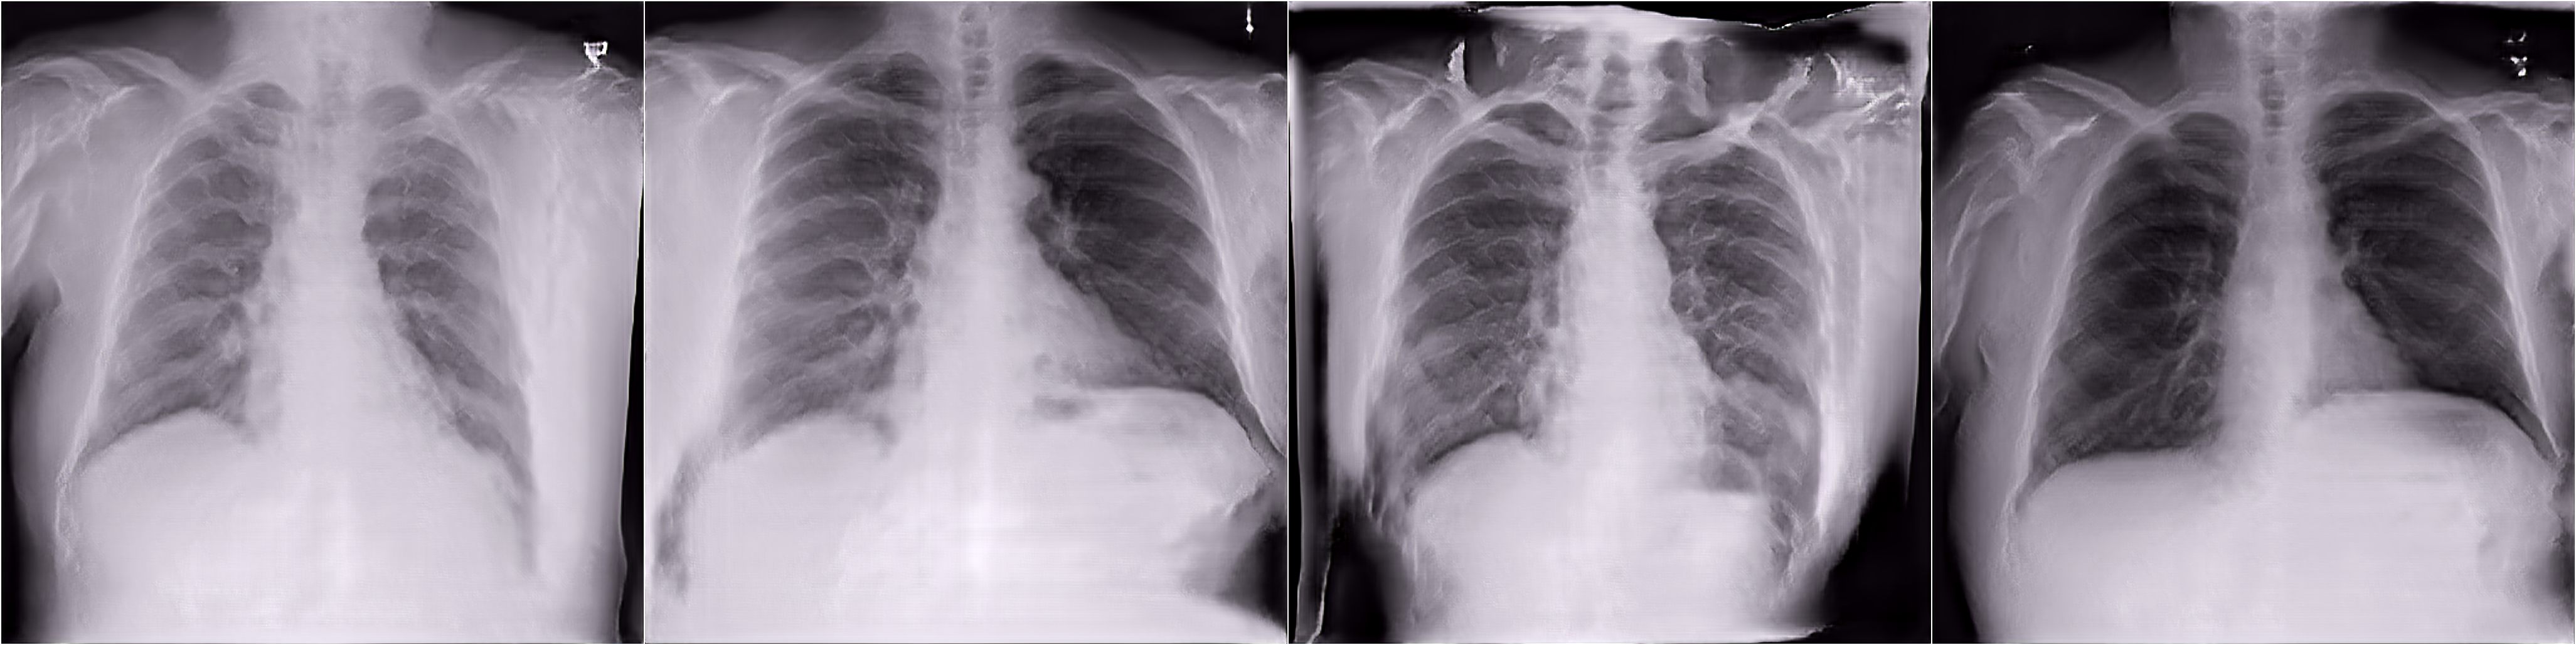

In [122]:
view_images(sample_dir, num_images=4)

The images look like chest x-rays. 

The project will work model 10, named `00010_FASTGAN_POLYP_PATCHES_W_MASKS`.

In [ ]:
model_id = 10
polyp_dir = output_dir / "polyp_samples"

generators.generate(
    model_id,
    num_samples=8,
    output_path=sample_dir,
)

print(
    f"Created {len(list(polyp_dir.glob('*')))} images (should be twice the number asked for)"
)